# Tarea: Seaborn para EDA

En este notebook se desarrollan tres visualizaciones aplicadas al dataset Iris, siguiendo los conceptos de análisis exploratorio de datos aprendidos en la sesión 41.

## Importación de bibliotecas y carga de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Carga del dataset Iris
df = pd.read_csv("iris.csv")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Exploración inicial de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
# Estadísticas descriptivas
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# Verificar valores únicos en la columna target (especie)
print("Especies (target):", df["target"].unique())
print("Conteo por especie:")
print(df["target"].value_counts())

Especies (target): [0 1 2]
Conteo por especie:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [6]:
# Crear etiquetas para las especies
especies = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}
df["especie"] = df["target"].map(especies)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


## Gráfico 1: Scatterplot de largo vs ancho del pétalo

Se utiliza un diagrama de dispersión para analizar la relación entre el largo y ancho del pétalo, diferenciando por especie.

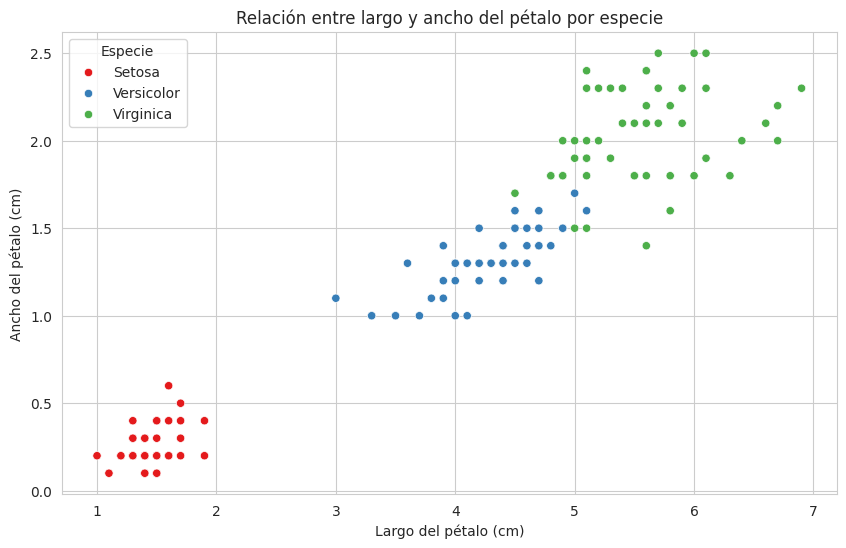

In [7]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="especie", palette="Set1")
plt.title("Relación entre largo y ancho del pétalo por especie")
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.legend(title="Especie")
plt.show()

Se observa una correlación positiva clara entre el largo y ancho del pétalo. Las tres especies forman grupos distinguibles, siendo Setosa la más separada con pétalos más pequeños, mientras que Versicolor y Virginica tienen cierto traslape en valores intermedios.

## Gráfico 2: Boxplot del ancho del sépalo por especie

Se utiliza un boxplot para comparar la distribución del ancho del sépalo entre las diferentes especies.

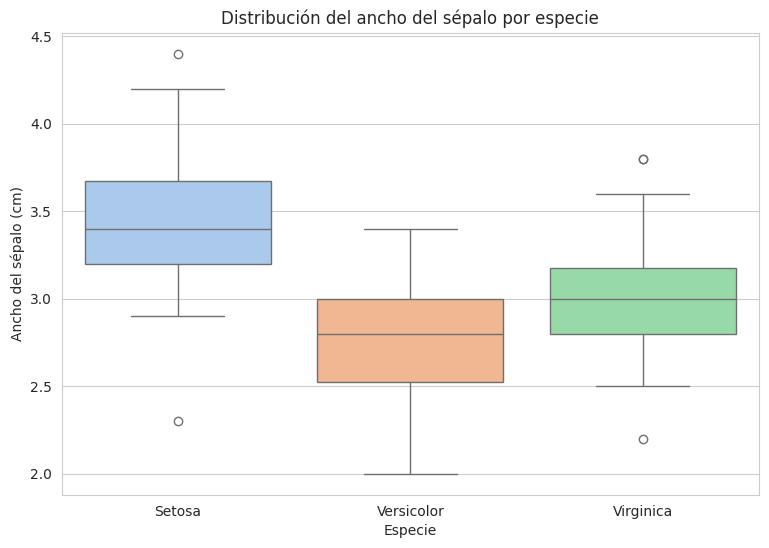

In [11]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="especie", hue="especie", y="sepal width (cm)", palette="pastel")
plt.title("Distribución del ancho del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Ancho del sépalo (cm)")
plt.show()

El boxplot revela que Setosa presenta mayor ancho de sépalo en promedio comparado con las otras especies. Se detectan algunos outliers en Versicolor y Virginica, lo cual indica la presencia de valores atípicos en esas categorías.

## Gráfico 3: Heatmap de correlación

Se genera un mapa de calor para visualizar las correlaciones entre todas las variables numéricas del dataset.

In [9]:
# Calcular matriz de correlación (solo columnas numéricas)
columnas_numericas = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
correlacion = df[columnas_numericas].corr()
correlacion

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


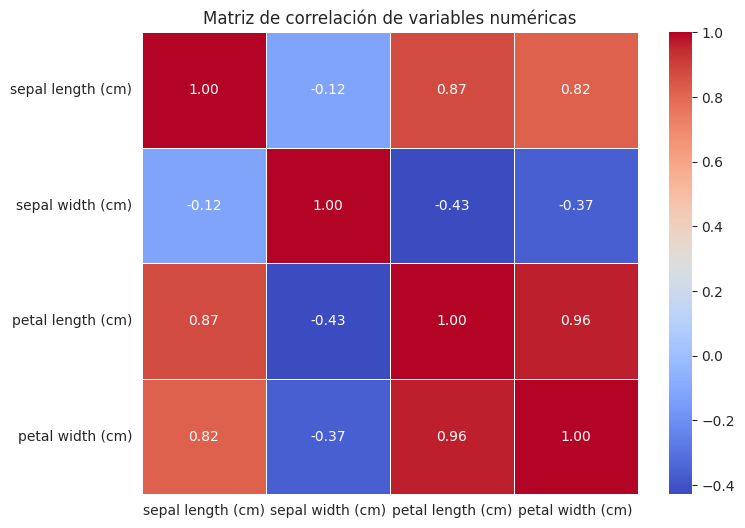

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

El heatmap muestra correlaciones fuertes entre el largo y ancho del pétalo (0.96), así como entre el largo del pétalo y el largo del sépalo (0.87). En contraste, el ancho del sépalo presenta correlaciones débiles o negativas con las demás variables, lo que sugiere que esta medida aporta información diferenciada.

## Conclusiones

El análisis exploratorio permitió identificar patrones importantes en el dataset Iris. El scatterplot evidenció la separabilidad de las especies por características del pétalo, el boxplot mostró diferencias en las distribuciones del sépalo y la detección de outliers, mientras que el heatmap reveló las relaciones lineales entre las variables numéricas.